Machine Learning-Based Customer Churn Prediction for Consulting Firms

In [2]:
pip install pandas numpy scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
#STEP 1: Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


In [4]:
#STEP 2: Load the CSV File
df = pd.read_csv("PrimePath_Contacts_15000.csv")
print(df.shape)
df.head()


(15000, 48)


,ContactID,FirstName,LastName,FullName,Email,SecondaryEmail,Phone,MobilePhone,OtherPhone,JobTitle,...,UpdatedBy,IsActive,ProfilePictureURL,Notes,Interests,CustomField1,CustomField2,CustomField3,CustomField4,CustomField5
0,1,Priya,Nair,Priya Nair,priya.nair1@outlook.com,NaN,915500265774,912871422713,NaN,Digital Marketing Lead,...,36,True,NaN,NaN,NaN,NaN,Tuesday,Intermediate,Morning 9-11 IST,NaN
1,2,Ananya,Kumar,Ananya Kumar,ananya.kumar2@outlook.com,NaN,44687203229,971248611757,NaN,Operations Manager,...,88,False,NaN,NaN,NaN,Sellerboard,NaN,Intermediate,Evening,NaN
2,3,Priya,Nair,Priya Nair,priya.nair3@outlook.com,NaN,916617575030,971225078951,NaN,Category Manager,...,76,True,NaN,NaN,NaN,NaN,Monday,NaN,NaN,NaN
3,4,Emily,Iyer,Emily Iyer,emily.iyer4@yahoo.co.in,NaN,919547810444,916904382144,NaN,Brand Manager,...,59,True,NaN,NaN,NaN,Seller Central,Monday,Beginner,Afternoon 2-5 IST,NaN
4,5,Rahul,Sharma,Rahul Sharma,rahul.sharma5@yahoo.co.in,NaN,44058008495,910065326321,NaN,Brand Manager,...,39,True,NaN,NaN,NaN,NaN,Friday,Certified,Afternoon 2-5 IST,NaN


In [5]:
#STEP 3: Create the TARGET COLUMN (Churn)
df["Churn"] = np.where(
    (df["LifecycleStage"].isin(["Churned", "Inactive"])) |
    (df["HealthScore"] < 4) |
    (df["EngagementScore"] < 30),
    1,
    0
)

In [6]:
#STEP 4: Select ONLY SAFE FEATURES
features = [
    "EngagementScore",
    "HealthScore",
    "NPSLastScore",
    "CSATScore",
    "IsActive",
    "DoNotContact"
]

X = df[features]
y = df["Churn"]

In [7]:
#STEP 5: Handle Missing Values (NO ERRORS RULE)
X = X.fillna(0)

In [8]:
#STEP 6: Convert True/False → Numbers
X["IsActive"] = X["IsActive"].astype(int)
X["DoNotContact"] = X["DoNotContact"].astype(int)

In [9]:
#STEP 7: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
#STEP 8: Train the ML Model 
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

In [11]:
#STEP 9: Predictions & Accuracy
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy * 100)


Accuracy: 87.63333333333333


In [12]:
#STEP 10: Detailed Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.74      1.00      0.85      1064
           1       1.00      0.81      0.89      1936

    accuracy                           0.88      3000
   macro avg       0.87      0.90      0.87      3000
weighted avg       0.91      0.88      0.88      3000



In [13]:
#STEP 11: Get Feature Importance from Model
importances = model.feature_importances_
feature_names = X.columns

In [15]:
#STEP 12: Create a DataFrame for Easy Plotting
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

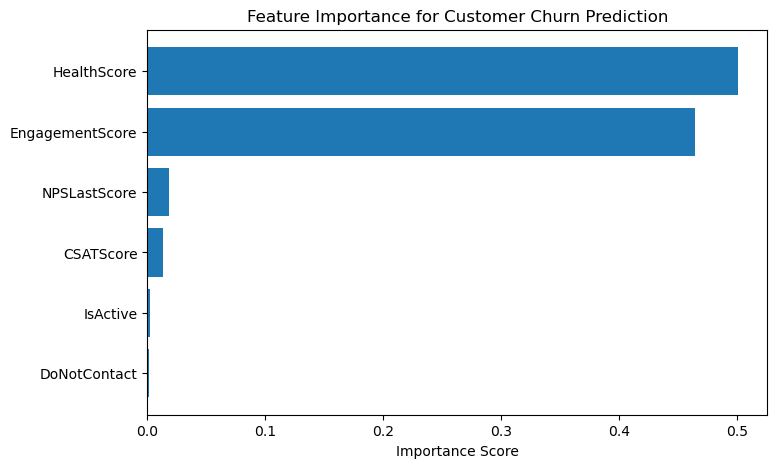

In [16]:
#STEP 13: Plot the Bar Chart
plt.figure(figsize=(8,5))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Importance Score")
plt.title("Feature Importance for Customer Churn Prediction")
plt.gca().invert_yaxis()
plt.show()

In [17]:
#STEP 14: Create Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1064    0]
 [ 371 1565]]


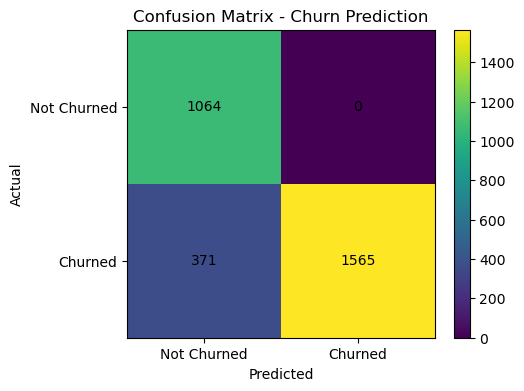

In [18]:
#STEP 15: Plot Confusion Matrix
plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.title("Confusion Matrix - Churn Prediction")
plt.colorbar()

plt.xticks([0,1], ["Not Churned", "Churned"])
plt.yticks([0,1], ["Not Churned", "Churned"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
